# **ENERGY LOAD CONSUMPTION FORECASTING (REGRESSION)**



## SECTION 1: Data Acquisition & Preprocessing

---



### 1.1 Real-World Dataset Loading and Directory Configuration

In [1]:
"""
DATA SOURCE:
- These datasets are real operational time-series collected by NETIX.AI's IoT platform.
- Specifically, they come from Power Monitoring Units (PMU) on two electrical panels:
  - PMU LRP-1
  - PMU LRP-2

JUSTIFICATION:
- Real building electrical telemetry is ideal for load forecasting (regression) because
  it contains timestamped measurements of power, voltage, current, PF, etc.
"""
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from pathlib import Path

#mounting files
from google.colab import drive
drive.mount("/content/drive")

RAW_DIR = Path("/content/drive/MyDrive/CSV/data_raw/regression")
CLEAN_DIR = Path("/content/drive/MyDrive/CSV/data_clean/regression")
CLEAN_DIR.mkdir(parents=True, exist_ok=True)

PMU1_FILE = RAW_DIR / "PMU LRP 1 full.xlsx"
PMU2_FILE = RAW_DIR / "PMU LRP 2 full.xlsx"

print("Raw folder:", RAW_DIR)
print("Output folder:", CLEAN_DIR)
print("PMU1 exists:", PMU1_FILE.exists())
print("PMU2 exists:", PMU2_FILE.exists())


Mounted at /content/drive
Raw folder: /content/drive/MyDrive/CSV/data_raw/regression
Output folder: /content/drive/MyDrive/CSV/data_clean/regression
PMU1 exists: True
PMU2 exists: True


### 1.2 Data Cleaning & Feature Engineering Helper Functions

In [2]:
def standardize_df(df: pd.DataFrame) -> pd.DataFrame:
    """
    Cleans raw data:
    - Parses timestamp
    - Drops *_str duplicate columns
    - Converts remaining columns to numeric (coerce errors to NaN)
    """
    df = df.copy()

    if "timestamp" not in df.columns:
        raise ValueError("No 'timestamp' column found.")

    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    df = df.dropna(subset=["timestamp"])

    str_cols = [c for c in df.columns if c.lower().endswith("_str")]
    df = df.drop(columns=str_cols, errors="ignore")

    for c in df.columns:
        if c == "timestamp":
            continue
        df[c] = pd.to_numeric(df[c], errors="coerce")

    return df


def find_col(df: pd.DataFrame, keywords) -> str:
    """Find the first column whose name contains ALL keywords (case-insensitive)."""
    for c in df.columns:
        name = c.lower()
        if all(k.lower() in name for k in keywords):
            return c
    raise ValueError(f"Could not find a column containing keywords: {keywords}")


def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    """Feature engineering: extract calendar/time signals."""
    df = df.copy()
    ts = df["timestamp"]
    df["hour"] = ts.dt.hour
    df["dayofweek"] = ts.dt.dayofweek
    df["month"] = ts.dt.month
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)
    return df


def add_lag_rolling(df: pd.DataFrame, target_col: str,
                    lags=(1, 2, 3, 6, 12),
                    roll_windows=(4, 12)) -> pd.DataFrame:
    """
    Adds:
    - lag features: previous target values
    - rolling stats: mean/std to capture trends & volatility
    """
    df = df.copy().sort_values("timestamp")

    for lag in lags:
        df[f"{target_col}_lag{lag}"] = df[target_col].shift(lag)

    for w in roll_windows:
        df[f"{target_col}_rmean{w}"] = df[target_col].rolling(w).mean()
        df[f"{target_col}_rstd{w}"] = df[target_col].rolling(w).std()

    return df


### 1.3 Raw Data Loading, Cleaning & Target Column Identification

In [3]:
pmu1_raw = pd.read_excel(PMU1_FILE)
pmu2_raw = pd.read_excel(PMU2_FILE)

pmu1 = standardize_df(pmu1_raw)
pmu2 = standardize_df(pmu2_raw)

print("PMU1 cleaned shape:", pmu1.shape)
print("PMU2 cleaned shape:", pmu2.shape)

pmu1_power_col = find_col(pmu1, ["realtime", "active", "power"])
pmu2_power_col = find_col(pmu2, ["realtime", "active", "power"])

print("PMU1 active power column:", pmu1_power_col)
print("PMU2 active power column:", pmu2_power_col)

pmu1.head()


PMU1 cleaned shape: (32673, 28)
PMU2 cleaned shape: (30302, 28)
PMU1 active power column: 158685_PMU LRP - 1_19704_REALTIME_ACTIVE POWER_KW
PMU2 active power column: 158686_PMU LRP - 2_19947_REALTIME_ACTIVE POWER_KW


,timestamp,158685_PMU LRP - 1_19704_REALTIME_ACTIVE POWER_KW,158685_PMU LRP - 1_19705_WATTS_R_PHASE,158685_PMU LRP - 1_19706_WATTS_Y_PHASE,158685_PMU LRP - 1_19707_WATTS_B_PHASE,158685_PMU LRP - 1_19708_PF_AVG,158685_PMU LRP - 1_19709_PF_R_PHASE,158685_PMU LRP - 1_19710_PF_Y_PHASE,158685_PMU LRP - 1_19711_PF_B_PHASE,158685_PMU LRP - 1_19712_AVG_CURRENT,...,158685_PMU LRP - 1_19721_Y_PHASE_VOLTAGE,158685_PMU LRP - 1_19722_B_PHASE_VOLTAGE,158685_PMU LRP - 1_19723_PRE_R_PHASE_KWH_IMPORT,158685_PMU LRP - 1_19724_PRE_Y_PHASE_KWH_IMPORT,158685_PMU LRP - 1_19725_PRE_B_PHASE_KWH_IMPORT,158685_PMU LRP - 1_19726_PRE_R_PHASE_KWH_EXPORT,158685_PMU LRP - 1_19727_PRE_Y_PHASE_KWH_EXPORT,158685_PMU LRP - 1_19728_PRE_B_PHASE_KWH_EXPORT,158685_PMU LRP - 1_19729_LINE TO LINE_VOLTAGE,158685_PMU LRP - 1_19730_LINE TO NEUTRAL_VOLTAGE
0,2025-08-22 05:50:00,-6.89,-6.57,-2.25,1.94,-0.04,-0.11,-0.04,0.04,0.27,...,226.44,226.65,717190.12,733470.5,946812.38,-4815.63,-1567.55,-1584.14,392.10,226.66
1,2025-08-22 06:05:00,-6.63,-6.29,-1.87,1.52,-0.03,-0.11,-0.03,0.04,0.27,...,226.46,226.67,717190.12,733470.5,946812.38,-4816.86,-1567.98,-1584.54,392.13,226.62
2,2025-08-22 06:20:00,-5.37,-6.23,-1.71,2.58,-0.03,-0.12,-0.04,0.05,0.27,...,226.40,226.40,717190.12,733470.5,946812.38,-4818.51,-1568.52,-1585.12,391.92,226.36
3,2025-08-22 06:25:00,-6.81,-6.48,-1.90,1.57,-0.04,-0.11,-0.02,0.03,0.27,...,226.01,226.28,717190.12,733470.5,946812.38,-4819.03,-1568.69,-1585.31,391.44,226.25
4,2025-08-22 06:30:00,-6.80,-6.75,-1.56,1.51,-0.04,-0.11,-0.03,0.05,0.27,...,226.05,226.19,717190.12,733470.5,946812.38,-4819.58,-1568.85,-1585.49,391.43,226.20


### 1.4 Panel Data Merging & Total Load Target Construction

In [4]:
# Rename columns to avoid collisions
pmu1 = pmu1.rename(columns={c: f"pmu1_{c}" for c in pmu1.columns if c != "timestamp"})
pmu2 = pmu2.rename(columns={c: f"pmu2_{c}" for c in pmu2.columns if c != "timestamp"})

reg = pd.merge(pmu1, pmu2, on="timestamp", how="inner").sort_values("timestamp").reset_index(drop=True)
print("Merged dataset shape:", reg.shape)

# Best regression target: total building load = panel1 + panel2
pmu1_p = "pmu1_" + pmu1_power_col
pmu2_p = "pmu2_" + pmu2_power_col

reg["total_building_load_kw"] = reg[pmu1_p] + reg[pmu2_p]

# Remove missing target rows
reg = reg.dropna(subset=["total_building_load_kw"]).reset_index(drop=True)
print("After dropping missing target rows:", reg.shape)

reg[["timestamp", pmu1_p, pmu2_p, "total_building_load_kw"]].head()


Merged dataset shape: (21335, 55)
After dropping missing target rows: (21294, 56)


,timestamp,pmu1_158685_PMU LRP - 1_19704_REALTIME_ACTIVE POWER_KW,pmu2_158686_PMU LRP - 2_19947_REALTIME_ACTIVE POWER_KW,total_building_load_kw
0,2025-08-22 06:20:00,-5.37,5394.850,5389.480
1,2025-08-22 06:25:00,-6.81,5416.040,5409.230
2,2025-08-22 06:30:00,-6.80,5446.160,5439.360
3,2025-08-22 06:35:00,-6.48,5463.245,5456.765
4,2025-08-22 06:40:00,-6.07,5466.615,5460.545


## SECTION 2: Feature Engineering & Dataset Preparation

---



### 2.1 Time-Series Feature Engineering & Lag Generation

In [5]:
reg = add_time_features(reg)

# Toggle lag features ON/OFF
ADD_LAGS = True

if ADD_LAGS:
    reg = add_lag_rolling(
        reg,
        target_col="total_building_load_kw",
        lags=(1, 2, 3, 6, 12),
        roll_windows=(4, 12)
    )
    # lag/rolling creates NaNs at the start
    reg = reg.dropna().reset_index(drop=True)

print("Final regression dataset shape:", reg.shape)
reg.head()


Final regression dataset shape: (15361, 69)


,timestamp,pmu1_158685_PMU LRP - 1_19704_REALTIME_ACTIVE POWER_KW,pmu1_158685_PMU LRP - 1_19705_WATTS_R_PHASE,pmu1_158685_PMU LRP - 1_19706_WATTS_Y_PHASE,pmu1_158685_PMU LRP - 1_19707_WATTS_B_PHASE,pmu1_158685_PMU LRP - 1_19708_PF_AVG,pmu1_158685_PMU LRP - 1_19709_PF_R_PHASE,pmu1_158685_PMU LRP - 1_19710_PF_Y_PHASE,pmu1_158685_PMU LRP - 1_19711_PF_B_PHASE,pmu1_158685_PMU LRP - 1_19712_AVG_CURRENT,...,is_weekend,total_building_load_kw_lag1,total_building_load_kw_lag2,total_building_load_kw_lag3,total_building_load_kw_lag6,total_building_load_kw_lag12,total_building_load_kw_rmean4,total_building_load_kw_rstd4,total_building_load_kw_rmean12,total_building_load_kw_rstd12
0,2025-08-22 07:25:00,-7.69,-7.27,-2.57,2.15,-0.04,-0.13,-0.03,0.04,0.28,...,0,5362.880,5400.120,5389.470,5449.35,5389.480,5382.918750,15.855024,5423.140417,33.992821
1,2025-08-22 07:30:00,-6.54,-6.77,-2.49,2.72,-0.03,-0.12,-0.04,0.04,0.28,...,0,5379.205,5362.880,5400.120,5440.74,5409.230,5380.516250,15.247889,5420.692917,36.078756
2,2025-08-22 07:35:00,-5.52,-7.16,-2.40,1.78,-0.04,-0.12,-0.03,0.04,0.28,...,0,5379.860,5379.205,5362.880,5428.49,5439.360,5372.418750,8.453747,5414.723750,38.550418
3,2025-08-22 07:40:00,-6.88,-6.56,-2.33,1.40,-0.04,-0.11,-0.04,0.02,0.28,...,0,5367.730,5379.860,5379.205,5389.47,5456.765,5374.351250,6.103090,5407.544167,38.028077
4,2025-08-22 07:45:00,-7.06,-6.40,-3.14,1.98,-0.04,-0.11,-0.05,0.04,0.28,...,0,5370.610,5367.730,5379.860,5400.12,5460.545,5376.251667,8.734516,5401.399306,34.477034


### 2.2 Dataset Summary & Temporal Coverage Analysis

In [6]:
print("Rows:", len(reg))
print("Columns:", reg.shape[1])
print("Start timestamp:", reg["timestamp"].min())
print("End timestamp:", reg["timestamp"].max())

# Estimate typical sampling interval
dt = reg["timestamp"].sort_values().diff().dropna()
print("\nMost common time intervals (top 5):")
print(dt.value_counts().head(5))


Rows: 15361
Columns: 69
Start timestamp: 2025-08-22 07:25:00
End timestamp: 2025-12-18 04:40:00

Most common time intervals (top 5):
timestamp
0 days 00:05:00    7889
0 days 00:10:00    3386
0 days 00:15:00    1737
0 days 00:20:00     962
0 days 00:25:00     533
Name: count, dtype: int64


### 2.3 Data Quality Assessment & Target Distribution Analysis

Top 15 columns by missing %:
timestamp                                                 0.0
pmu1_158685_PMU LRP - 1_19704_REALTIME_ACTIVE POWER_KW    0.0
pmu1_158685_PMU LRP - 1_19705_WATTS_R_PHASE               0.0
pmu1_158685_PMU LRP - 1_19706_WATTS_Y_PHASE               0.0
pmu1_158685_PMU LRP - 1_19707_WATTS_B_PHASE               0.0
pmu1_158685_PMU LRP - 1_19708_PF_AVG                      0.0
pmu1_158685_PMU LRP - 1_19709_PF_R_PHASE                  0.0
pmu1_158685_PMU LRP - 1_19710_PF_Y_PHASE                  0.0
pmu1_158685_PMU LRP - 1_19711_PF_B_PHASE                  0.0
pmu1_158685_PMU LRP - 1_19712_AVG_CURRENT                 0.0
pmu1_158685_PMU LRP - 1_19713_R_PHASE_CURRENT             0.0
pmu1_158685_PMU LRP - 1_19714_Y_PHASE_CURRENT             0.0
pmu1_158685_PMU LRP - 1_19715_B_PHASE_CURRENT             0.0
pmu1_158685_PMU LRP - 1_19716_FREQUENCY                   0.0
pmu1_158685_PMU LRP - 1_19717_ENERGY                      0.0
dtype: float64

Target summary:
count    

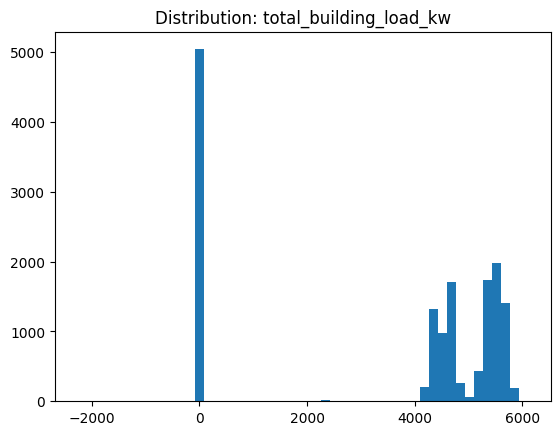

In [7]:
# Missing values %
missing_pct = (reg.isna().mean() * 100).sort_values(ascending=False)
print("Top 15 columns by missing %:")
print(missing_pct.head(15))

# Target distribution summary
target = reg["total_building_load_kw"]
print("\nTarget summary:")
print(target.describe())

# Quick outlier hint using IQR
q1, q3 = target.quantile(0.25), target.quantile(0.75)
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outlier_rate = ((target < low) | (target > high)).mean() * 100
print(f"\nOutlier rate (IQR rule): {outlier_rate:.2f}%")

import matplotlib.pyplot as plt
plt.figure()
plt.hist(target.values, bins=50)
plt.title("Distribution: total_building_load_kw")
plt.show()


### 2.4 Time-Based Dataset Splitting & Export

In [8]:
# Sort by time (must!)
reg = reg.sort_values("timestamp").reset_index(drop=True)

# -------------------------
# Create forecasting target (1-step ahead)
# We predict load at next timestamp using features at current timestamp.
# -------------------------
reg["target_kw"] = reg["total_building_load_kw"].shift(-1)
reg = reg.dropna(subset=["target_kw"]).reset_index(drop=True)


# 70% train, 15% validation, 15% test
n = len(reg)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = reg.iloc[:train_end].copy()
val_df = reg.iloc[train_end:val_end].copy()
test_df = reg.iloc[val_end:].copy()

print("Train:", train_df.shape, train_df["timestamp"].min(), "→", train_df["timestamp"].max())
print("Val:  ", val_df.shape,   val_df["timestamp"].min(),   "→", val_df["timestamp"].max())
print("Test: ", test_df.shape,  test_df["timestamp"].min(),  "→", test_df["timestamp"].max())

# Save to Drive
train_df.to_parquet(CLEAN_DIR / "regression_train.parquet", index=False)
val_df.to_parquet(CLEAN_DIR / "regression_val.parquet", index=False)
test_df.to_parquet(CLEAN_DIR / "regression_test.parquet", index=False)

# Also save the full master
reg.to_parquet(CLEAN_DIR / "regression_master.parquet", index=False)
reg.to_csv(CLEAN_DIR / "regression_master.csv", index=False)

print("\nSaved to:", CLEAN_DIR)


Train: (10752, 70) 2025-08-22 07:25:00 → 2025-11-16 12:35:00
Val:   (2304, 70) 2025-11-16 12:40:00 → 2025-12-02 23:45:00
Test:  (2304, 70) 2025-12-02 23:50:00 → 2025-12-18 04:30:00

Saved to: /content/drive/MyDrive/CSV/data_clean/regression


In [9]:
reg.head()

,timestamp,pmu1_158685_PMU LRP - 1_19704_REALTIME_ACTIVE POWER_KW,pmu1_158685_PMU LRP - 1_19705_WATTS_R_PHASE,pmu1_158685_PMU LRP - 1_19706_WATTS_Y_PHASE,pmu1_158685_PMU LRP - 1_19707_WATTS_B_PHASE,pmu1_158685_PMU LRP - 1_19708_PF_AVG,pmu1_158685_PMU LRP - 1_19709_PF_R_PHASE,pmu1_158685_PMU LRP - 1_19710_PF_Y_PHASE,pmu1_158685_PMU LRP - 1_19711_PF_B_PHASE,pmu1_158685_PMU LRP - 1_19712_AVG_CURRENT,...,total_building_load_kw_lag1,total_building_load_kw_lag2,total_building_load_kw_lag3,total_building_load_kw_lag6,total_building_load_kw_lag12,total_building_load_kw_rmean4,total_building_load_kw_rstd4,total_building_load_kw_rmean12,total_building_load_kw_rstd12,target_kw
0,2025-08-22 07:25:00,-7.69,-7.27,-2.57,2.15,-0.04,-0.13,-0.03,0.04,0.28,...,5362.880,5400.120,5389.470,5449.35,5389.480,5382.918750,15.855024,5423.140417,33.992821,5379.860000
1,2025-08-22 07:30:00,-6.54,-6.77,-2.49,2.72,-0.03,-0.12,-0.04,0.04,0.28,...,5379.205,5362.880,5400.120,5440.74,5409.230,5380.516250,15.247889,5420.692917,36.078756,5367.730000
2,2025-08-22 07:35:00,-5.52,-7.16,-2.40,1.78,-0.04,-0.12,-0.03,0.04,0.28,...,5379.860,5379.205,5362.880,5428.49,5439.360,5372.418750,8.453747,5414.723750,38.550418,5370.610000
3,2025-08-22 07:40:00,-6.88,-6.56,-2.33,1.40,-0.04,-0.11,-0.04,0.02,0.28,...,5367.730,5379.860,5379.205,5389.47,5456.765,5374.351250,6.103090,5407.544167,38.028077,5386.806667
4,2025-08-22 07:45:00,-7.06,-6.40,-3.14,1.98,-0.04,-0.11,-0.05,0.04,0.28,...,5370.610,5367.730,5379.860,5400.12,5460.545,5376.251667,8.734516,5401.399306,34.477034,5385.453333


## SECTION 3: — Regression (Energy Forecasting)

---


This section trains 4 regression models to forecast **next-step building load** (1-step ahead) using PMU sensor features + engineered time/lag/rolling features.

**Important leakage fix (rolling features):** rolling statistics must use *past values only*. We compute rolling on `shift(1)` so the model never sees the current target inside its own features.

**Forecast target:** `target_kw = total_building_load_kw shifted by -1` (predict next timestamp load from current features).


### 3.1 Leakage-Safe Feature Engineering (Rolling on Past Only)

In [10]:
def add_lag_rolling(df: pd.DataFrame, target_col: str,
                    lags=(1, 2, 3, 6, 12),
                    roll_windows=(4, 12)) -> pd.DataFrame:
    """
    Adds lag and rolling features without leakage:
    - Lags: y(t-1), y(t-2), ...
    - Rolling mean/std computed on past only via shift(1)
    """
    df = df.copy().sort_values("timestamp")

    # Lags (safe)
    for lag in lags:
        df[f"{target_col}_lag{lag}"] = df[target_col].shift(lag)

    # Rolling on past only (safe)
    past = df[target_col].shift(1)
    for w in roll_windows:
        df[f"{target_col}_rmean{w}"] = past.rolling(w).mean()
        df[f"{target_col}_rstd{w}"]  = past.rolling(w).std()

    return df

### 3.2 Load Train / Validation / Test Splits
We load the saved parquet splits from Google Drive. Then we create `X` (features) and `y` (target).

**Missing values:** we fill NaNs using **training medians only** (simple + no leakage).

In [11]:
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = "/content/drive/MyDrive/CSV/data_clean/regression"

train_df = pd.read_parquet(f"{BASE_PATH}/regression_train.parquet")
val_df   = pd.read_parquet(f"{BASE_PATH}/regression_val.parquet")
test_df  = pd.read_parquet(f"{BASE_PATH}/regression_test.parquet")

TARGET = "target_kw"
DROP_COLS = ["timestamp"]

def make_Xy(df: pd.DataFrame):
    y = df[TARGET].astype(float)
    X = df.drop(columns=[TARGET] + DROP_COLS, errors="ignore")
    X = X.apply(pd.to_numeric, errors="coerce")
    X = X.replace([np.inf, -np.inf], np.nan)
    return X, y

X_train, y_train = make_Xy(train_df)
X_val, y_val     = make_Xy(val_df)
X_test, y_test   = make_Xy(test_df)

# Simple NaN handling (train medians only)
train_medians = X_train.median(numeric_only=True)
X_train = X_train.fillna(train_medians)
X_val   = X_val.fillna(train_medians)
X_test  = X_test.fillna(train_medians)

print("Shapes (X):", X_train.shape, X_val.shape, X_test.shape)
print("Target preview:", y_train.head().to_list()[:5])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shapes (X): (10752, 68) (2304, 68) (2304, 68)
Target preview: [5379.86, 5367.73, 5370.61, 5386.806666666667, 5385.453333333334]


### 3.3 Metrics & Plot Helpers
We evaluate using **MAE**, **RMSE**, and **R²**. We also plot a short segment of actual vs predicted values.

In [12]:
def eval_regression(y_true, y_pred, name="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name} Results:")
    print("MAE :", mae)
    print("RMSE:", rmse)
    print("R²  :", r2)

    return {"MAE": mae, "RMSE": rmse, "R2": r2}

def plot_actual_vs_pred(y_true, y_pred, title, n=None):
    """Line plot of actual vs predicted. Use n to limit points."""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    if n is not None:
        y_true = y_true[:n]
        y_pred = y_pred[:n]

    plt.figure(figsize=(10,4))
    plt.plot(y_true, label="Actual", linewidth=2)
    plt.plot(y_pred, label="Predicted", alpha=0.8)
    plt.title(title)
    plt.xlabel("Time index")
    plt.ylabel("kW")
    plt.legend()
    plt.show()

def plot_scatter_actual_pred(y_true, y_pred, title):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    plt.figure(figsize=(5,5))
    plt.scatter(y_true, y_pred, alpha=0.25)
    plt.title(title)
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.show()


### 3.4 Implementing Regression Models
We use a **time-based split** (Train/Validation/Test) with no shuffling. Models are tuned on the **validation** set and final performance is reported on the **test** set.

### 3.4.1 Linear Regression (Baseline)
A simple baseline model to establish reference performance.

#### 3.4.1.1 Train

In [13]:
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()
linreg.fit(X_train, y_train)

LinearRegression()

#### 3.4.1.2 Validate


Linear Regression (VAL) Results:
MAE : 172.17556303931363
RMSE: 1598.5344200962236
R²  : 0.5787666234753105


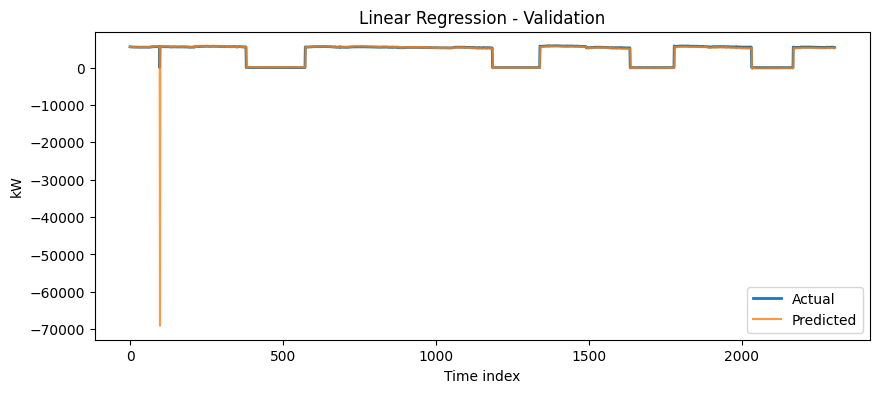

In [14]:
val_pred_lr = linreg.predict(X_val)
lr_metrics = eval_regression(y_val, val_pred_lr, "Linear Regression (VAL)")
plot_actual_vs_pred(y_val, val_pred_lr, "Linear Regression - Validation")

In [15]:
print(TARGET in X_train.columns)
print(X_train.columns[X_train.columns.str.contains("load", case=False)])

False
Index(['total_building_load_kw', 'total_building_load_kw_lag1',
       'total_building_load_kw_lag2', 'total_building_load_kw_lag3',
       'total_building_load_kw_lag6', 'total_building_load_kw_lag12',
       'total_building_load_kw_rmean4', 'total_building_load_kw_rstd4',
       'total_building_load_kw_rmean12', 'total_building_load_kw_rstd12'],
      dtype='object')


In [16]:
# Check correlation between features and target
corr = X_train.corrwith(y_train)
print(corr.sort_values(ascending=False).head(10))

total_building_load_kw                               0.989263
total_building_load_kw_rmean4                        0.980405
total_building_load_kw_lag1                          0.979013
total_building_load_kw_lag2                          0.968790
total_building_load_kw_lag3                          0.958635
total_building_load_kw_rmean12                       0.956431
total_building_load_kw_lag6                          0.931262
total_building_load_kw_lag12                         0.882702
pmu2_158686_PMU LRP - 2_19960_REACTIVE_POWER_KVAR    0.524191
pmu2_158686_PMU LRP - 2_19948_WATTS_R_PHASE          0.522611
dtype: float64


In [17]:
print(X_train.columns)

Index(['pmu1_158685_PMU LRP - 1_19704_REALTIME_ACTIVE POWER_KW',
       'pmu1_158685_PMU LRP - 1_19705_WATTS_R_PHASE',
       'pmu1_158685_PMU LRP - 1_19706_WATTS_Y_PHASE',
       'pmu1_158685_PMU LRP - 1_19707_WATTS_B_PHASE',
       'pmu1_158685_PMU LRP - 1_19708_PF_AVG',
       'pmu1_158685_PMU LRP - 1_19709_PF_R_PHASE',
       'pmu1_158685_PMU LRP - 1_19710_PF_Y_PHASE',
       'pmu1_158685_PMU LRP - 1_19711_PF_B_PHASE',
       'pmu1_158685_PMU LRP - 1_19712_AVG_CURRENT',
       'pmu1_158685_PMU LRP - 1_19713_R_PHASE_CURRENT',
       'pmu1_158685_PMU LRP - 1_19714_Y_PHASE_CURRENT',
       'pmu1_158685_PMU LRP - 1_19715_B_PHASE_CURRENT',
       'pmu1_158685_PMU LRP - 1_19716_FREQUENCY',
       'pmu1_158685_PMU LRP - 1_19717_ENERGY',
       'pmu1_158685_PMU LRP - 1_19718_APPARENT_POWER_KVA',
       'pmu1_158685_PMU LRP - 1_19719_REACTIVE_POWER_KVAR',
       'pmu1_158685_PMU LRP - 1_19720_R_PHASE_VOLTAGE',
       'pmu1_158685_PMU LRP - 1_19721_Y_PHASE_VOLTAGE',
       'pmu1_158685_PMU L

### 3.4.2 Random Forest Regressor
Ensemble of decision trees that can capture nonlinear relationships without requiring feature scaling.

#### 3.4.2.1 Train

In [18]:
from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(
    n_estimators=300,
    max_depth=18,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_reg.fit(X_train, y_train)

RandomForestRegressor(max_depth=18, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=300, n_jobs=-1, random_state=42)

#### 3.4.2.2 Validate


Random Forest Regressor (VAL) Results:
MAE : 603.5462360044561
RMSE: 906.6776792475308
R²  : 0.8644858517286206


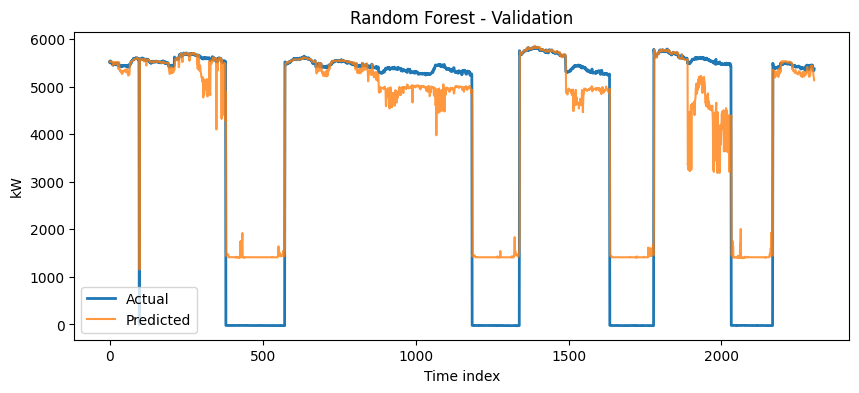

In [19]:
val_pred_rf = rf_reg.predict(X_val)
rf_metrics = eval_regression(y_val, val_pred_rf, "Random Forest Regressor (VAL)")
plot_actual_vs_pred(y_val, val_pred_rf, "Random Forest - Validation")

### 3.4.3 Support Vector Regressor (RBF)
SVR generally needs feature scaling. We apply StandardScaler **only for SVR** (kept minimal and explainable).

#### 3.4.3.1 Scale + Train

In [20]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

svr_scaler = StandardScaler()
X_train_svr = svr_scaler.fit_transform(X_train)
X_val_svr   = svr_scaler.transform(X_val)

svr = SVR(kernel="rbf", C=10, gamma="scale", epsilon=0.1)
svr.fit(X_train_svr, y_train)

SVR(C=10)

#### 3.4.3.2 Validate


SVR (RBF) (VAL) Results:
MAE : 750.268271231015
RMSE: 890.8076179971679
R²  : 0.8691882860748879


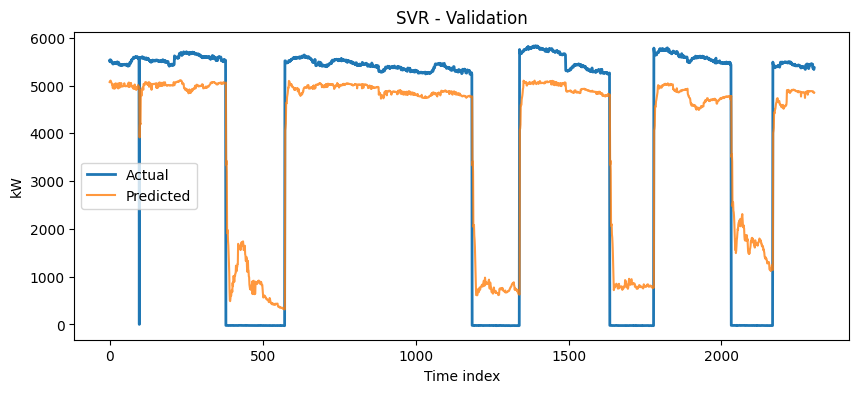

In [21]:
val_pred_svr = svr.predict(X_val_svr)
svr_metrics = eval_regression(y_val, val_pred_svr, "SVR (RBF) (VAL)")
plot_actual_vs_pred(y_val, val_pred_svr, "SVR - Validation")

### 3.4.4 Gradient Boosting Regressor
Boosting builds trees sequentially to reduce error.

#### 3.4.4.1 Train

In [23]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    random_state=42,
    n_estimators=400,
    learning_rate=0.05,
    max_depth=3
)
gbr.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.05, n_estimators=400, random_state=42)

#### 3.4.4.2 Validate


Gradient Boosting Regressor (VAL) Results:
MAE : 1366.4598940231915
RMSE: 2371.704090966601
R²  : 0.07274369172188866


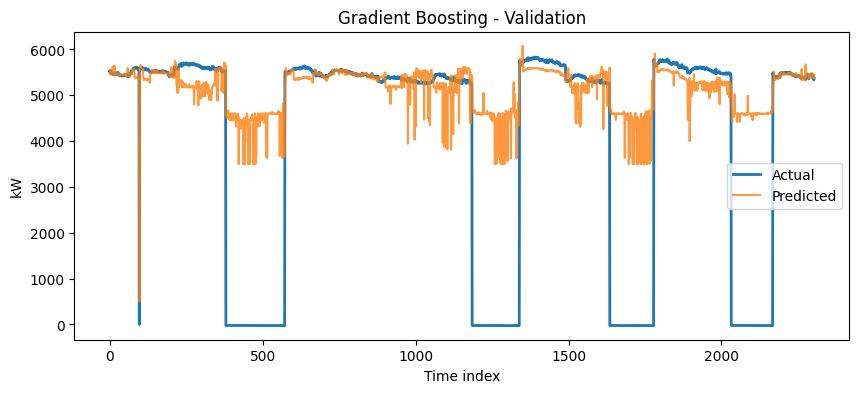

In [24]:
val_pred_gbr = gbr.predict(X_val)
gbr_metrics = eval_regression(y_val, val_pred_gbr, "Gradient Boosting Regressor (VAL)")
plot_actual_vs_pred(y_val, val_pred_gbr, "Gradient Boosting - Validation")

### 3.5 Model Comparison (Validation)
We compare models on the validation set. Lower **RMSE** is better; higher **R²** is better.

In [25]:
results_val = pd.DataFrame([
    {"Model":"LinearRegression", "MAE": lr_metrics["MAE"], "RMSE": lr_metrics["RMSE"], "R2": lr_metrics["R2"]},
    {"Model":"RandomForest",     "MAE": rf_metrics["MAE"], "RMSE": rf_metrics["RMSE"], "R2": rf_metrics["R2"]},
    {"Model":"SVR_RBF",          "MAE": svr_metrics["MAE"], "RMSE": svr_metrics["RMSE"], "R2": svr_metrics["R2"]},
    {"Model":"GradBoost",        "MAE": gbr_metrics["MAE"], "RMSE": gbr_metrics["RMSE"], "R2": gbr_metrics["R2"]},
]).sort_values("RMSE")

results_val

,Model,MAE,RMSE,R2
2,SVR_RBF,750.268271,890.807618,0.869188
1,RandomForest,603.546236,906.677679,0.864486
0,LinearRegression,172.175563,1598.534420,0.578767
3,GradBoost,1366.459894,2371.704091,0.072744


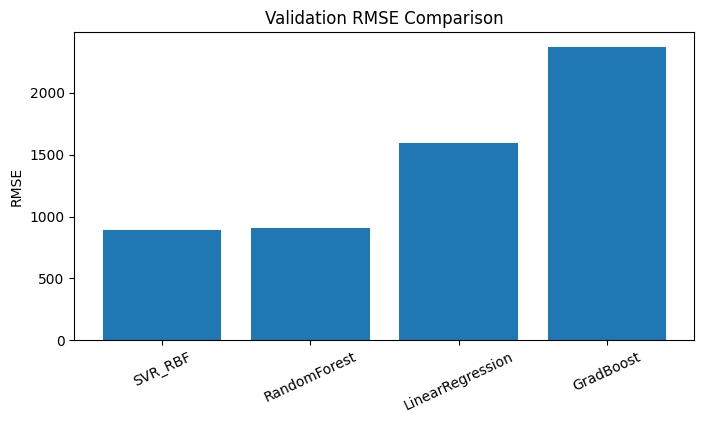

In [26]:
# Visual comparison (Validation RMSE)
plt.figure(figsize=(8,4))
plt.bar(results_val["Model"], results_val["RMSE"])
plt.title("Validation RMSE Comparison")
plt.ylabel("RMSE")
plt.xticks(rotation=25)
plt.show()


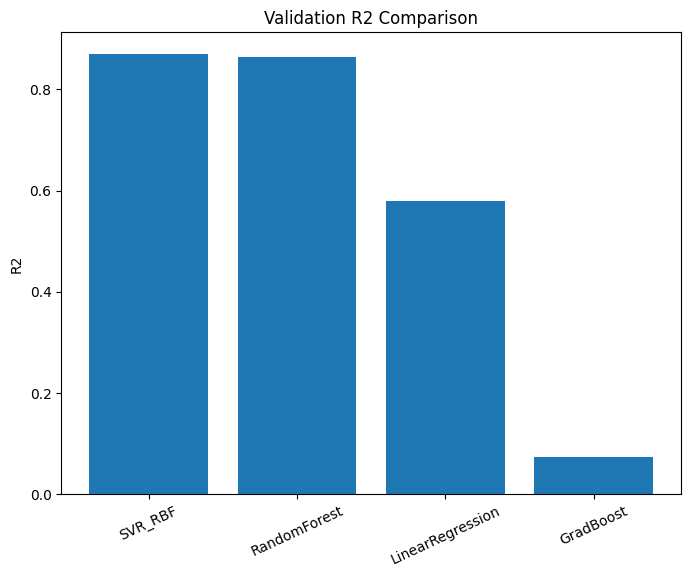

In [32]:
# Visual comparison (Validation R2)
plt.figure(figsize=(8,6))
plt.bar(results_val["Model"], results_val["R2"])
plt.title("Validation R2 Comparison")
plt.ylabel("R2")
plt.xticks(rotation=25)
plt.show()


### 3.6 Final Training (Train+Val) + Test Evaluation
We retrain the best validation model on **Train + Validation**, then evaluate once on the **Test** set.

Best model on VAL: SVR_RBF

SVR_RBF (TEST) Results:
MAE : 340.8525844962308
RMSE: 490.2191009783604
R²  : 0.9679620283202215


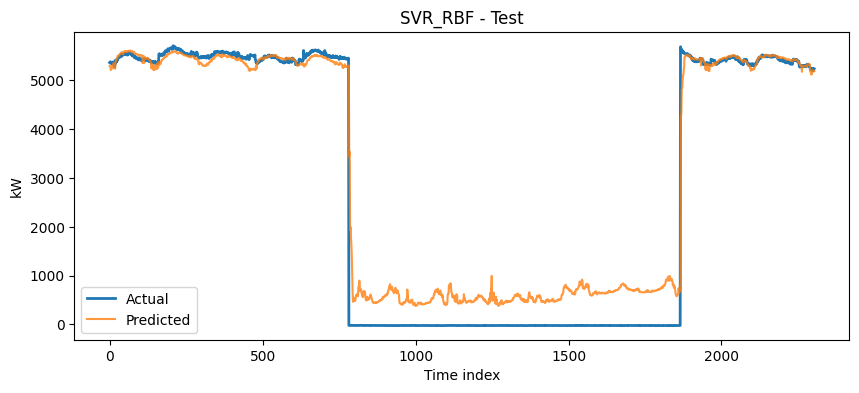

In [33]:
# Combine train + validation
X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

best_name = results_val.iloc[0]["Model"]
print("Best model on VAL:", best_name)

if best_name == "LinearRegression":
    final_model = LinearRegression().fit(X_trainval, y_trainval)
    test_pred = final_model.predict(X_test)

elif best_name == "RandomForest":
    final_model = RandomForestRegressor(
        n_estimators=300, max_depth=18,
        min_samples_split=5, min_samples_leaf=2,
        random_state=42, n_jobs=-1
    ).fit(X_trainval, y_trainval)
    test_pred = final_model.predict(X_test)

elif best_name == "SVR_RBF":
    final_scaler = StandardScaler()
    X_trainval_s = final_scaler.fit_transform(X_trainval)
    X_test_s     = final_scaler.transform(X_test)

    final_model = SVR(kernel="rbf", C=10, gamma="scale", epsilon=0.1)
    final_model.fit(X_trainval_s, y_trainval)
    test_pred = final_model.predict(X_test_s)

else:  # GradBoost
    final_model = GradientBoostingRegressor(
        random_state=42, n_estimators=400, learning_rate=0.05, max_depth=3
    ).fit(X_trainval, y_trainval)
    test_pred = final_model.predict(X_test)

test_metrics = eval_regression(y_test, test_pred, f"{best_name} (TEST)")
plot_actual_vs_pred(y_test, test_pred, f"{best_name} - Test")

### 3.7 Error Analysis (Regression)
We analyze residuals (Actual − Predicted) to understand bias and where the model struggles.


In [34]:
residuals = y_test.values - test_pred

print("Residual summary:")
print(pd.Series(residuals).describe())


Residual summary:
count    2304.000000
mean     -274.787839
std       406.051686
min     -5326.790926
25%      -602.479708
50%       -67.004332
75%        37.603044
max      4818.476175
dtype: float64


#### 3.7.1 Residual Plot (Predicted vs Residual)

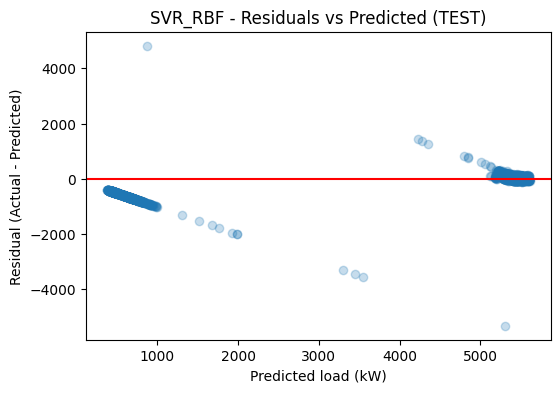

In [35]:
plt.figure(figsize=(6,4))
plt.scatter(test_pred, residuals, alpha=0.25)
plt.axhline(0, color="red")
plt.title(f"{best_name} - Residuals vs Predicted (TEST)")
plt.xlabel("Predicted load (kW)")
plt.ylabel("Residual (Actual - Predicted)")
plt.show()


#### 3.7.2 Residual Distribution

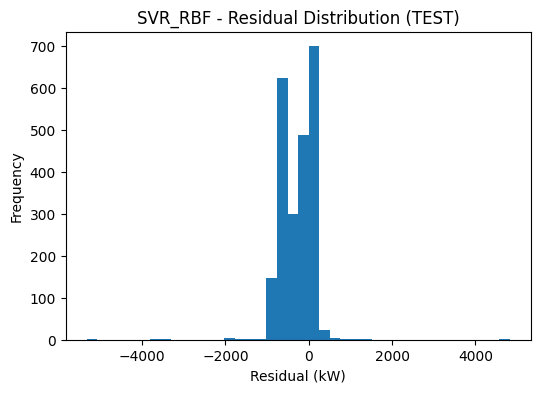

In [36]:
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=40)
plt.title(f"{best_name} - Residual Distribution (TEST)")
plt.xlabel("Residual (kW)")
plt.ylabel("Frequency")
plt.show()


#### 3.7.3 Absolute Error Over Time (first 1000 points)

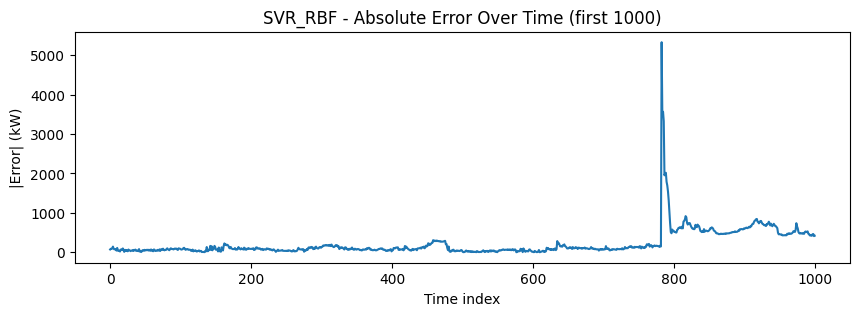

In [38]:
abs_err = np.abs(residuals)

plt.figure(figsize=(10,3))
plt.plot(abs_err[:1000])
plt.title(f"{best_name} - Absolute Error Over Time (first 1000)")
plt.xlabel("Time index")
plt.ylabel("|Error| (kW)")
plt.show()
